Starting Evaluation on MeGlass_Real...
Found 114 positive pairs.
MEASURING: Positive Pairs...


100%|██████████| 114/114 [07:06<00:00,  3.74s/it]


MEASURING: Negative Pairs...


100%|██████████| 2000/2000 [1:59:44<00:00,  3.59s/it]  



EVALUATION RESULTS: MeGlass_Real
Best Accuracy: 99.29% at Threshold 0.58
FMR (False Match Rate / FAR):    0.50%
FNMR (False Non-Match Rate / FRR): 4.39%
------------------------------------------------------------
CONFUSION MATRIX (Text):
                       PREDICTED: MATCH    PREDICTED: DIFF
        ACTUAL: SAME           109 (TP)             5 (FN)
        ACTUAL: DIFF            10 (FP)          1990 (TN)
------------------------------------------------------------
BIOMETRIC STANDARD REPORT (FNMR @ Fixed FMR)
------------------------------------------------------------
Condition 1: FMR ≈ 1.0% (Security: 1 in 100)
   - Threshold used: 0.6603
   - Actual FMR:     1.3500%
    Result FNMR:   4.39%
------------------------------------------------------------
Condition 2: FMR ≈ 0.1% (Security: 1 in 1,000)
   - Threshold used: -inf
   - Actual FMR:     0.0000%
   Result FNMR:   100.00%


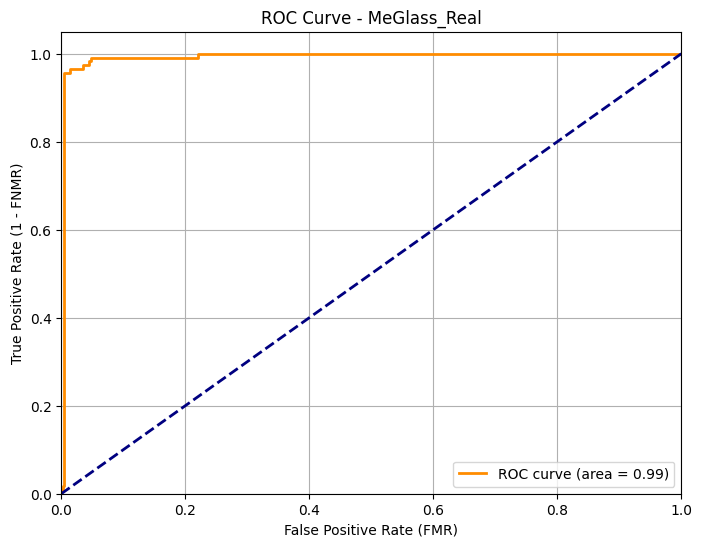

ROC Curve saved as 'ROC_MeGlass_Real.png'


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc

# ================= CONFIGURATION =================
# เลือกเปลี่ยน Path ตาม Dataset ที่จะวัด (ทำทีละรอบ)

# --- SET 1: สำหรับ FFHQ (วัด ROC) ---
#GEN_DIR = r"D:\senior_project\evaluation_data\generatedsyn_v9_myproject_resized"
#GT_DIR = r"D:\senior_project\evaluation_data\ground_truth_synthetic_resized"
#DATASET_NAME = "FFHQ_Synthetic"
#NUM_NEGATIVE_PAIRS = 300 

# --- SET 2: สำหรับ MeGlass วัดแบบ glasses(วัด FMR/FNMR) ---
#GEN_DIR = r"D:\senior_project\evaluation_data\Meglass_results"
#GT_DIR = r"D:\senior_project\dataset\Meglass_evaluation\without_glasses"
#DATASET_NAME = "MeGlass_Real"
#NUM_NEGATIVE_PAIRS = 2000

# --- SET 3: สำหรับ MeGlass วัดแบบ non_glasses(วัด FMR/FNMR) ---
GEN_DIR = r"D:\senior_project\dataset\Meglass_evaluation\without_glasses"
GT_DIR = r"D:\senior_project\dataset\Meglass_evaluation\without_glasses_for_bye"
DATASET_NAME = "MeGlass_Real"
NUM_NEGATIVE_PAIRS = 2000

MODEL_NAME = "ArcFace"
DETECTOR_BACKEND = "mtcnn"
# ====================================================

def get_person_id(filename):
    if '@' in filename: return filename.rpartition('@')[0]
    return filename.split('.')[0] 

# 1. จับคู่ไฟล์
print(f"Starting Evaluation on {DATASET_NAME}...")
gt_map = {get_person_id(f): f for f in os.listdir(GT_DIR) if f.lower().endswith(('.jpg','.png'))}
gen_files = [f for f in os.listdir(GEN_DIR) if f.lower().endswith(('.jpg','.png'))]

paired_data = []
for f_gen in gen_files:
    pid = get_person_id(f_gen)
    if pid in gt_map:
        paired_data.append((f_gen, gt_map[pid]))

print(f"Found {len(paired_data)} positive pairs.")

# 2. รัน DeepFace เก็บค่า Distance และ Label
y_true = []   
y_scores = [] 

# --- Positive Pairs (คนเดียวกัน) ---
print("MEASURING: Positive Pairs...")
for f_gen, f_gt in tqdm(paired_data):
    try:
        result = DeepFace.verify(
            img1_path=os.path.join(GEN_DIR, f_gen),
            img2_path=os.path.join(GT_DIR, f_gt),
            model_name=MODEL_NAME, enforce_detection=False, detector_backend=DETECTOR_BACKEND
        )
        y_true.append(1) 
        y_scores.append(result['distance'])
    except: pass

# --- Negative Pairs (คนละคน) ---
print("MEASURING: Negative Pairs...")
negative_pairs = []
if len(paired_data) >= 2:
    for i in range(NUM_NEGATIVE_PAIRS):
        pair1, pair2 = random.sample(paired_data, 2)
        if get_person_id(pair1[0]) != get_person_id(pair2[1]): 
            negative_pairs.append((pair1[0], pair2[1]))

for f_gen, f_gt in tqdm(negative_pairs):
    try:
        result = DeepFace.verify(
            img1_path=os.path.join(GEN_DIR, f_gen),
            img2_path=os.path.join(GT_DIR, f_gt),
            model_name=MODEL_NAME, enforce_detection=False, detector_backend=DETECTOR_BACKEND
        )
        y_true.append(0) 
        y_scores.append(result['distance'])
    except: pass

# ================= CALCULATION =================
y_true = np.array(y_true)
y_scores = np.array(y_scores)

# หา Threshold ที่ดีที่สุด
thresholds = np.linspace(0, 1.5, 100)
best_acc = 0
best_thresh = 0
fmr_at_best = 0
fnmr_at_best = 0

# ตัวแปรสำหรับเก็บ Confusion Matrix ที่ดีที่สุด
best_tp = 0
best_tn = 0
best_fp = 0
best_fn = 0

for th in thresholds:
    pred = y_scores < th 
    
    tp = np.sum((pred == 1) & (y_true == 1))
    tn = np.sum((pred == 0) & (y_true == 0))
    fp = np.sum((pred == 1) & (y_true == 0)) 
    fn = np.sum((pred == 0) & (y_true == 1)) 
    
    acc = (tp + tn) / len(y_true)
    
    if acc > best_acc:
        best_acc = acc
        best_thresh = th
        fmr_at_best = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnmr_at_best = fn / (tp + fn) if (tp + fn) > 0 else 0
        
        # เก็บค่า Matrix ณ จุดที่ดีที่สุดไว้โชว์
        best_tp = tp
        best_tn = tn
        best_fp = fp
        best_fn = fn

# ================= 1. GENERAL REPORT =================
print("\n" + "="*60)
print(f"EVALUATION RESULTS: {DATASET_NAME}")
print("="*60)
print(f"Best Accuracy: {best_acc*100:.2f}% at Threshold {best_thresh:.2f}")
print(f"FMR (False Match Rate / FAR):    {fmr_at_best*100:.2f}%")
print(f"FNMR (False Non-Match Rate / FRR): {fnmr_at_best*100:.2f}%")
print("-" * 60)

# ================= 2. CONFUSION MATRIX (Text) =================
print(f"CONFUSION MATRIX (Text):")
print(f"{'':>20} {'PREDICTED: MATCH':>18} {'PREDICTED: DIFF':>18}")
print(f"{'ACTUAL: SAME':>20} {str(best_tp) + ' (TP)':>18} {str(best_fn) + ' (FN)':>18}")
print(f"{'ACTUAL: DIFF':>20} {str(best_fp) + ' (FP)':>18} {str(best_tn) + ' (TN)':>18}")
print("-" * 60)

# ================= 3. BIOMETRIC STANDARD REPORT (FNMR @ Fixed FMR) =================
print(f"BIOMETRIC STANDARD REPORT (FNMR @ Fixed FMR)")
print("-" * 60)

# คำนวณ ROC Curve
max_dist = np.max(y_scores)
y_similarity = max_dist - y_scores 
fpr, tpr, roc_thresholds = roc_curve(y_true, y_similarity) # เก็บ roc_thresholds แยกไว้

# คำนวณ FNR (False Negative Rate)
fnr = 1 - tpr

# สร้างฟังก์ชันคำนวณหา FNMR เมื่อกำหนด FMR ที่ต้องการ
def get_fnmr_at_fmr(fpr, fnr, thresholds, target_fmr):
    # หา index ที่ค่า fpr ใกล้เคียงกับ target_fmr มากที่สุด
    idx = np.nanargmin(np.abs(fpr - target_fmr))
    return fnr[idx], thresholds[idx], fpr[idx]

# Condition 1: FNMR at FMR = 0.01 (1%)
target_fmr_1 = 0.01
fnmr_1, thresh_1, actual_fmr_1 = get_fnmr_at_fmr(fpr, fnr, roc_thresholds, target_fmr_1)

# Condition 2: FNMR at FMR = 0.001 (0.1%)
target_fmr_2 = 0.001
fnmr_2, thresh_2, actual_fmr_2 = get_fnmr_at_fmr(fpr, fnr, roc_thresholds, target_fmr_2)

# แสดงผล
print(f"Condition 1: FMR ≈ {target_fmr_1*100}% (Security: 1 in 100)")
print(f"   - Threshold used: {max_dist - thresh_1:.4f}") 
print(f"   - Actual FMR:     {actual_fmr_1*100:.4f}%")
print(f"    Result FNMR:   {fnmr_1*100:.2f}%")
print("-" * 60)

print(f"Condition 2: FMR ≈ {target_fmr_2*100}% (Security: 1 in 1,000)")
print(f"   - Threshold used: {max_dist - thresh_2:.4f}")
print(f"   - Actual FMR:     {actual_fmr_2*100:.4f}%")
print(f"   Result FNMR:   {fnmr_2*100:.2f}%")
print("="*60)

# ================= 4. PLOT ROC CURVE =================
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FMR)')
plt.ylabel('True Positive Rate (1 - FNMR)')
plt.title(f'ROC Curve - {DATASET_NAME}')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f'ROC_{DATASET_NAME}.png')
plt.show()

print(f"ROC Curve saved as 'ROC_{DATASET_NAME}.png'")